In [3]:
!pip install mlxtend networkx pandas matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
transactions = []
# Nhóm khách hàng thích nấu ăn (mua trọn bộ Herb) - Tạo mối liên kết mạnh
for _ in range(500):
    transactions.append(['HERB MARKER THYME', 'HERB MARKER PARSLEY', 'HERB MARKER ROSEMARY', 'HERB MARKER BASIL'])
for _ in range(300):
    transactions.append(['HERB MARKER THYME', 'HERB MARKER PARSLEY', 'HERB MARKER MINT'])
for _ in range(200):
    transactions.append(['HERB MARKER CHIVES', 'HERB MARKER PARSLEY', 'HERB MARKER THYME'])

# Nhóm khách hàng vãng lai (mua đồ khác, tạo nhiễu)
for _ in range(1000):
    items = np.random.choice(['MILK', 'BREAD', 'EGGS', 'WATER', 'APPLE', 'NAPKIN'], size=np.random.randint(1, 4), replace=False)
    transactions.append(list(items))

# --- 2. CHUYỂN ĐỔI SANG ONE-HOT ENCODING (BASKET FORMAT) ---
# Theo tài liệu: Dữ liệu chuyển sang ma trận Boolean [cite: 229]
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_basket = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Kích thước ma trận giỏ hàng: {df_basket.shape}")
df_basket.head()

Kích thước ma trận giỏ hàng: (2000, 12)


,APPLE,BREAD,EGGS,HERB MARKER BASIL,HERB MARKER CHIVES,HERB MARKER MINT,HERB MARKER PARSLEY,HERB MARKER ROSEMARY,HERB MARKER THYME,MILK,NAPKIN,WATER
0,False,False,False,True,False,False,True,True,True,False,False,False
1,False,False,False,True,False,False,True,True,True,False,False,False
2,False,False,False,True,False,False,True,True,True,False,False,False
3,False,False,False,True,False,False,True,True,True,False,False,False
4,False,False,False,True,False,False,True,True,True,False,False,False


In [5]:
# --- 3. ÁP DỤNG APRIORI ---
# Tham số từ báo cáo: min_support = 0.01 [cite: 236]
frequent_itemsets = apriori(df_basket, min_support=0.01, use_colnames=True)

# Sinh luật kết hợp
# Tham số từ báo cáo: metric="lift", min_threshold=1.0 [cite: 237-238]
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Lọc luật theo ngưỡng đề xuất trong bài [cite: 242-243]
# min_conf = 0.3, min_lift = 1.2
filtered_rules = rules[
    (rules['confidence'] >= 0.3) &
    (rules['lift'] >= 1.2)
]

# Sắp xếp giảm dần theo Lift và Confidence [cite: 256]
filtered_rules = filtered_rules.sort_values(['lift', 'confidence'], ascending=False)

print(f"Số lượng luật tìm thấy: {len(filtered_rules)}")
filtered_rules.head()

Số lượng luật tìm thấy: 67


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
26,(HERB MARKER ROSEMARY),(HERB MARKER BASIL),0.25,0.25,0.25,1.0,4.0,1.0,0.1875,inf,1.0,1.0,1.0,1.0
27,(HERB MARKER BASIL),(HERB MARKER ROSEMARY),0.25,0.25,0.25,1.0,4.0,1.0,0.1875,inf,1.0,1.0,1.0,1.0
68,"(HERB MARKER PARSLEY, HERB MARKER ROSEMARY)",(HERB MARKER BASIL),0.25,0.25,0.25,1.0,4.0,1.0,0.1875,inf,1.0,1.0,1.0,1.0
69,"(HERB MARKER PARSLEY, HERB MARKER BASIL)",(HERB MARKER ROSEMARY),0.25,0.25,0.25,1.0,4.0,1.0,0.1875,inf,1.0,1.0,1.0,1.0
72,(HERB MARKER ROSEMARY),"(HERB MARKER PARSLEY, HERB MARKER BASIL)",0.25,0.25,0.25,1.0,4.0,1.0,0.1875,inf,1.0,1.0,1.0,1.0


c:\Users\Mr Vinh\.conda\envs\dataminingnew\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\Mr Vinh\.conda\envs\dataminingnew\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\Mr Vinh\.conda\envs\dataminingnew\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


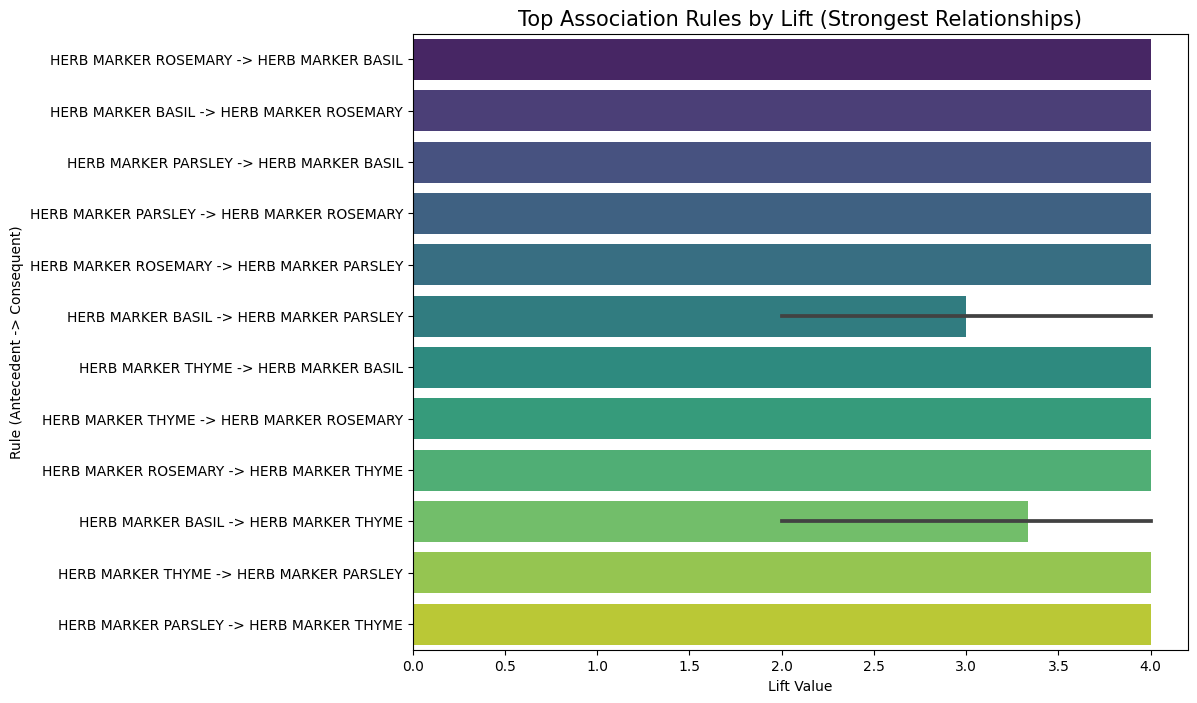

In [6]:
# --- 4. TRỰC QUAN HÓA: TOP 50 LUẬT THEO LIFT ---

# Chọn Top 20 luật để vẽ cho thoáng (thay vì 50)
top_rules = filtered_rules.head(20).copy()

# Tạo chuỗi mô tả luật để làm nhãn trục Y (A -> B)
top_rules['rule_desc'] = top_rules['antecedents'].apply(lambda x: list(x)[0]) + " -> " + top_rules['consequents'].apply(lambda x: list(x)[0])

plt.figure(figsize=(10, 8))
sns.barplot(x="lift", y="rule_desc", data=top_rules, palette="viridis")
plt.title("Top Association Rules by Lift (Strongest Relationships)", fontsize=15)
plt.xlabel("Lift Value")
plt.ylabel("Rule (Antecedent -> Consequent)")
plt.show()

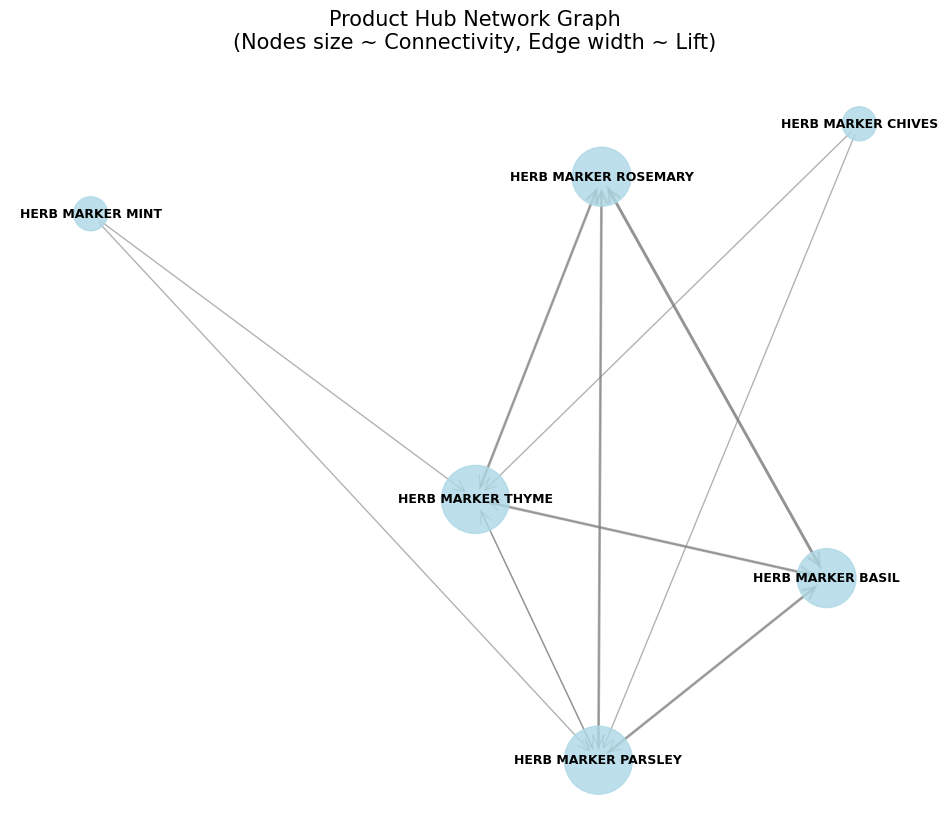

In [7]:
# --- 5. TRỰC QUAN HÓA: NETWORK GRAPH (PRODUCT HUB) ---

def draw_network_graph(rules, top_n=30):
    # Lấy top luật mạnh nhất để vẽ
    rules_to_show = rules.head(top_n)
    
    # Khởi tạo đồ thị có hướng
    G = nx.DiGraph()
    
    # Thêm nút và cạnh
    for i, row in rules_to_show.iterrows():
        ant = list(row['antecedents'])[0]
        con = list(row['consequents'])[0]
        weight = row['lift']
        
        # Thêm cạnh nối: Antecedent -> Consequent
        # Độ dày cạnh (weight) dựa trên Lift
        G.add_edge(ant, con, weight=weight)
    
    # Tính toán vị trí các nút (Layout)
    pos = nx.spring_layout(G, k=1.5, seed=42) # k càng lớn các nút càng xa nhau
    
    plt.figure(figsize=(12, 10))
    
    # 1. Vẽ các nút (Nodes)
    # Tính bậc (degree) của nút để xác định kích thước -> Nút nào nhiều kết nối là HUB
    d = dict(G.degree)
    nx.draw_networkx_nodes(G, pos, node_size=[v * 300 for v in d.values()], 
                           node_color='lightblue', alpha=0.8)
    
    # 2. Vẽ các cạnh (Edges)
    # Độ đậm nhạt của cạnh dựa trên Lift
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    # Chuẩn hóa độ dày để vẽ đẹp hơn
    width = [w * 0.5 for w in weights] # Scale down lift for visualization
    
    nx.draw_networkx_edges(G, pos, width=width, edge_color='grey', alpha=0.6, arrowstyle='->', arrowsize=20)
    
    # 3. Vẽ nhãn (Labels)
    nx.draw_networkx_labels(G, pos, font_size=9, font_family="sans-serif", font_weight="bold")
    
    plt.title("Product Hub Network Graph\n(Nodes size ~ Connectivity, Edge width ~ Lift)", fontsize=15)
    plt.axis('off')
    plt.show()

# Gọi hàm vẽ
draw_network_graph(filtered_rules)